## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```

In [ ]:
# Assign your and your partner's names here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

# **t-SNE and Word Embeddings Visualization**

In this notebook exercise, we will explore **t-SNE (t-Distributed Stochastic Neighbor Embedding)**, a powerful non-linear dimensionality reduction technique that is particularly well-suited for visualizing high-dimensional data.

## **Why t-SNE for Word Embeddings?**

Word embeddings like those from spaCy capture semantic relationships between words in high-dimensional space (typically 50-300 dimensions). However, visualizing these relationships requires reducing them to 2D or 3D.

**t-SNE advantages**:
- **Preserves local structure**: Words with similar meanings cluster together
- **Non-linear**: Captures complex relationships better than linear methods like PCA
- **Excellent for visualization**: Produces clear, interpretable 2D/3D plots

## **What is t-SNE?**

t-SNE is an unsupervised learning technique that:
1. Computes pairwise similarities between points in high-dimensional space
2. Computes pairwise similarities in low-dimensional space
3. Minimizes the difference between these similarities using gradient descent
4. Emphasizes preserving local neighborhoods over global structure

Unlike PCA, t-SNE is **non-linear** and focuses on keeping similar items close together rather than maximizing variance.

## **Objectives**

In this exercise, you will:
1. Load pre-trained spaCy word embeddings
2. Select grocery store food words
3. Extract their high-dimensional vector representations
4. Apply t-SNE to reduce to 2D
5. Visualize semantic relationships between food categories

## **Import Libraries**

Let's start by importing the necessary libraries for our analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import subprocess
import sys
import spacy

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

# Try to load the spaCy model, if not available, download it
try:
    nlp = spacy.load('en_core_web_md')
    print("spaCy model 'en_core_web_md' loaded successfully!")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_md"])
    nlp = spacy.load('en_core_web_md')
    print("Download and load complete!")

Download and load complete!


## **Load spaCy Word Embeddings**

We'll use pre-trained word embeddings from spaCy's `en_core_web_md` model. This model is trained on web data and captures semantic relationships between words.

**Key advantages of spaCy**:
- **Easy installation**: One command to download
- **Good quality**: Trained on web text, captures semantic relationships well

The `en_core_web_md` model includes word vectors for common English words, which we'll use to represent our grocery store food items.

## **Define Grocery Store Food Words**

Let's select a diverse set of food items you would typically find at a grocery store, organized by category.

In [2]:
# Define grocery store food words by category
food_words = {
    'Fruits': ['apple', 'banana', 'orange', 'strawberry', 'grape', 'watermelon', 'peach', 'mango', 'pineapple', 'blueberry'],
    'Vegetables': ['carrot', 'broccoli', 'spinach', 'tomato', 'lettuce', 'cucumber', 'onion', 'potato', 'celery', 'corn'],
    'Meats': ['chicken', 'beef', 'pork', 'turkey', 'lamb', 'bacon', 'sausage', 'ham'],
    'Seafood': ['salmon', 'tuna', 'shrimp', 'crab', 'lobster', 'fish'],
    'Dairy': ['milk', 'cheese', 'butter', 'yogurt', 'cream', 'eggs'],
    'Grains': ['bread', 'rice', 'pasta', 'cereal', 'oatmeal', 'wheat', 'flour'],
    'Snacks': ['chips', 'cookies', 'crackers', 'popcorn', 'pretzels', 'candy'],
    'Beverages': ['coffee', 'tea', 'juice', 'soda', 'water', 'beer', 'wine'],
    'Condiments': ['ketchup', 'mustard', 'mayonnaise', 'vinegar', 'salt', 'pepper', 'sauce'],
    'Desserts': ['cake', 'pie', 'chocolate', 'ice', 'pudding']
}

# Flatten the dictionary to get all words and their categories
all_words = []
word_categories = {}
for category, words in food_words.items():
    for word in words:
        all_words.append(word)
        word_categories[word] = category
categories = list(food_words.keys())

print(f"Total number of food words: {len(all_words)}")
print(f"\nCategories: {list(food_words.keys())}")
print(f"\nSample words: {all_words[:10]}")

Total number of food words: 72

Categories: ['Fruits', 'Vegetables', 'Meats', 'Seafood', 'Dairy', 'Grains', 'Snacks', 'Beverages', 'Condiments', 'Desserts']

Sample words: ['apple', 'banana', 'orange', 'strawberry', 'grape', 'watermelon', 'peach', 'mango', 'pineapple', 'blueberry']


### **Plot Embeddings**

In [3]:
def plot_embeddings(words_to_plot, word_vectors_2d, word_categories, title=None):
    plt.figure(figsize=(16, 12))

    # Create a color map for categories
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
    category_colors = {cat: colors[i] for i, cat in enumerate(categories)}

    # Plot each word
    for i, word in enumerate(words_to_plot):
        category = word_categories[word]
        x, y = word_vectors_2d[i]
        
        plt.scatter(x, y, c=[category_colors[category]], s=300, alpha=0.6, edgecolors='black', linewidth=1)
        plt.annotate(word, (x, y), fontsize=24, alpha=0.8, ha='center')

    # Create legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=category_colors[cat], 
                                markersize=10, label=cat, alpha=0.6)
                    for cat in categories]
    plt.legend(handles=legend_elements, loc='best', fontsize=11, title='Food Categories')

    plot_title = title if title else 't-SNE Visualization of spaCy Word Embeddings for Grocery Store Foods'
    plt.title(plot_title, fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Extract Word Vectors**

Extract the spaCy word vectors for our food words.

- Create a list to store the vectors
- Create a list to store the words that have embeddings
- Loop through all_words and check if each word exists in embeddings_dict
- If it exists, add the vector and word to the respective lists
- Print how many words were found vs missing

In [4]:
word_vector_dict = {}

for word in all_words:
    # get spaCy embedding for the word (lexeme vector)
    embedding = nlp.vocab[word].vector
    word_vector_dict[word] = embedding

word_vectors = np.array(list(word_vector_dict.values()))

print(f"\nWord vectors shape: {word_vectors.shape}")


Word vectors shape: (72, 300)


## **Explore Word Vector Properties**

Let's examine some properties of our word vectors to understand what we're working with.

In [5]:
# Display statistics about the word vectors
print("Word Vector Statistics:")
print(f"Mean: {word_vectors.mean():.4f}")
print(f"Std: {word_vectors.std():.4f}")
print(f"Min: {word_vectors.min():.4f}")
print(f"Max: {word_vectors.max():.4f}")

# Show an example vector
print(f"\nExample: Vector for '{all_words[0]}' (first 10 dimensions):")
print(word_vector_dict[all_words[0]][:10])

Word Vector Statistics:
Mean: -0.0123
Std: 0.4375
Min: -2.8596
Max: 1.8898

Example: Vector for 'apple' (first 10 dimensions):
[-0.6334    0.18981  -0.53544  -0.52658  -0.30001   0.30559  -0.49303
  0.14636   0.012273  0.96802 ]


## **TASK 1: Apply t-SNE**

Now let's apply t-SNE to reduce our high-dimensional word vectors (96 dimensions from spaCy) to 2 dimensions for visualization.

**t-SNE Parameters**:
- `n_components=2`: Reduce to 2 dimensions
- `perplexity=30`: Balance between local and global structure (typical range: 5-50)
- `learning_rate=200`: Step size for optimization (typical range: 10-1000)
- `max_iter=1000`: Number of optimization iterations
- `random_state=42`: For reproducibility

**Note**: t-SNE can take a minute or two to run, especially with larger datasets.

In [6]:
print("Applying t-SNE dimensionality reduction...")

# Write your code here
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

word_vectors_2d = tsne.fit_transform(word_vectors)

print(f"\nt-SNE complete!")
print(f"Original shape: {word_vectors.shape}")
print(f"Reduced shape: {word_vectors_2d.shape}")

Applying t-SNE dimensionality reduction...

t-SNE complete!
Original shape: (72, 300)
Reduced shape: (72, 2)


## **Visualize the t-SNE Results**

Applying t-SNE with perplexity=2...


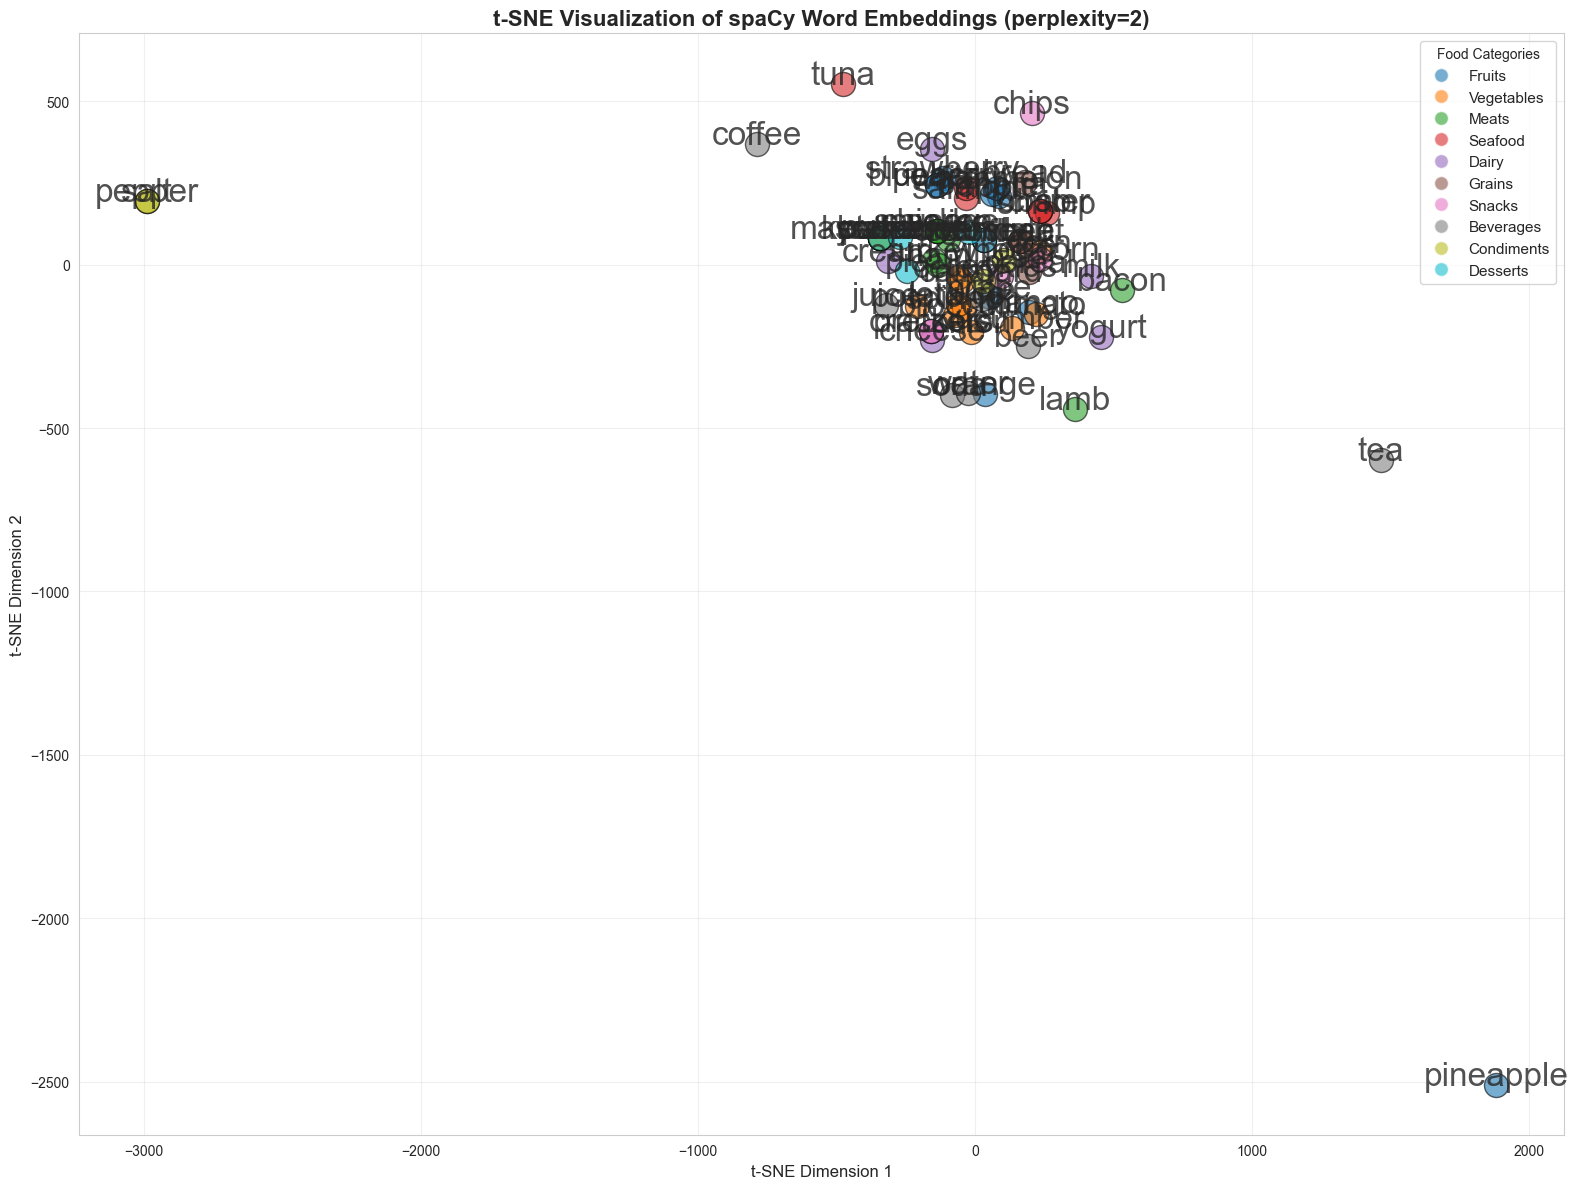

Applying t-SNE with perplexity=10...


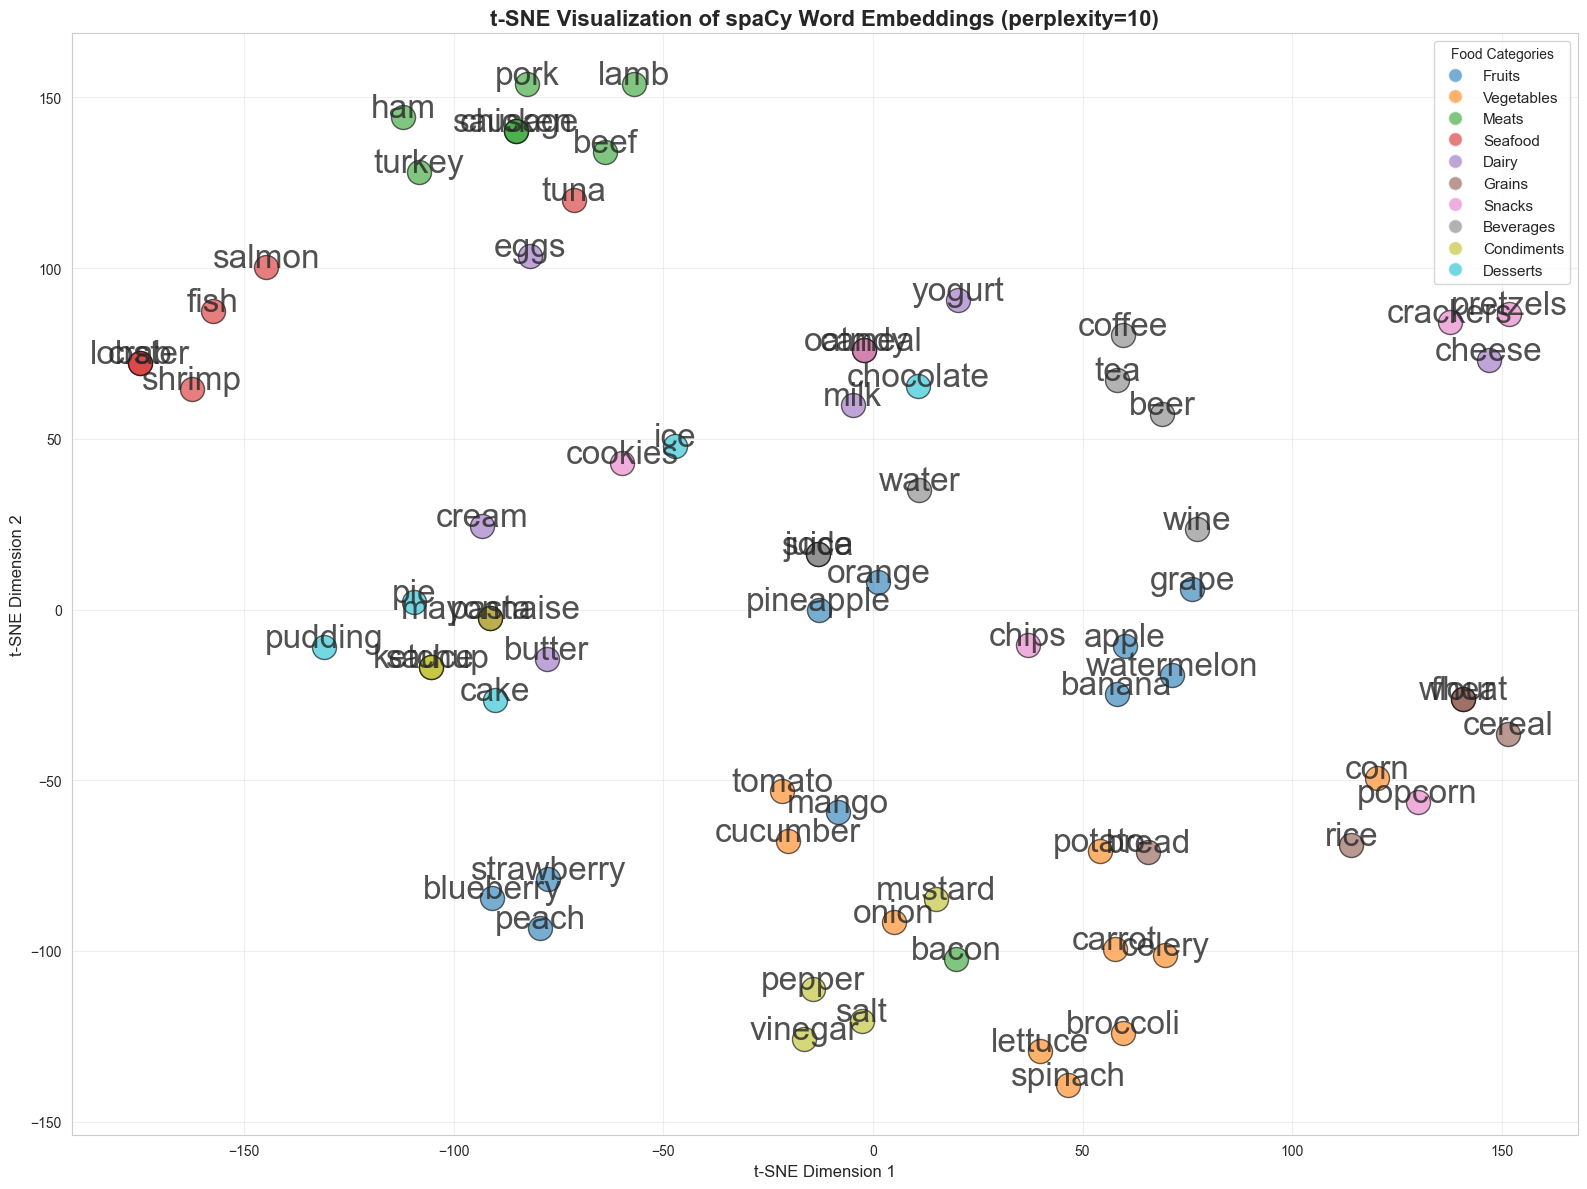

Applying t-SNE with perplexity=50...


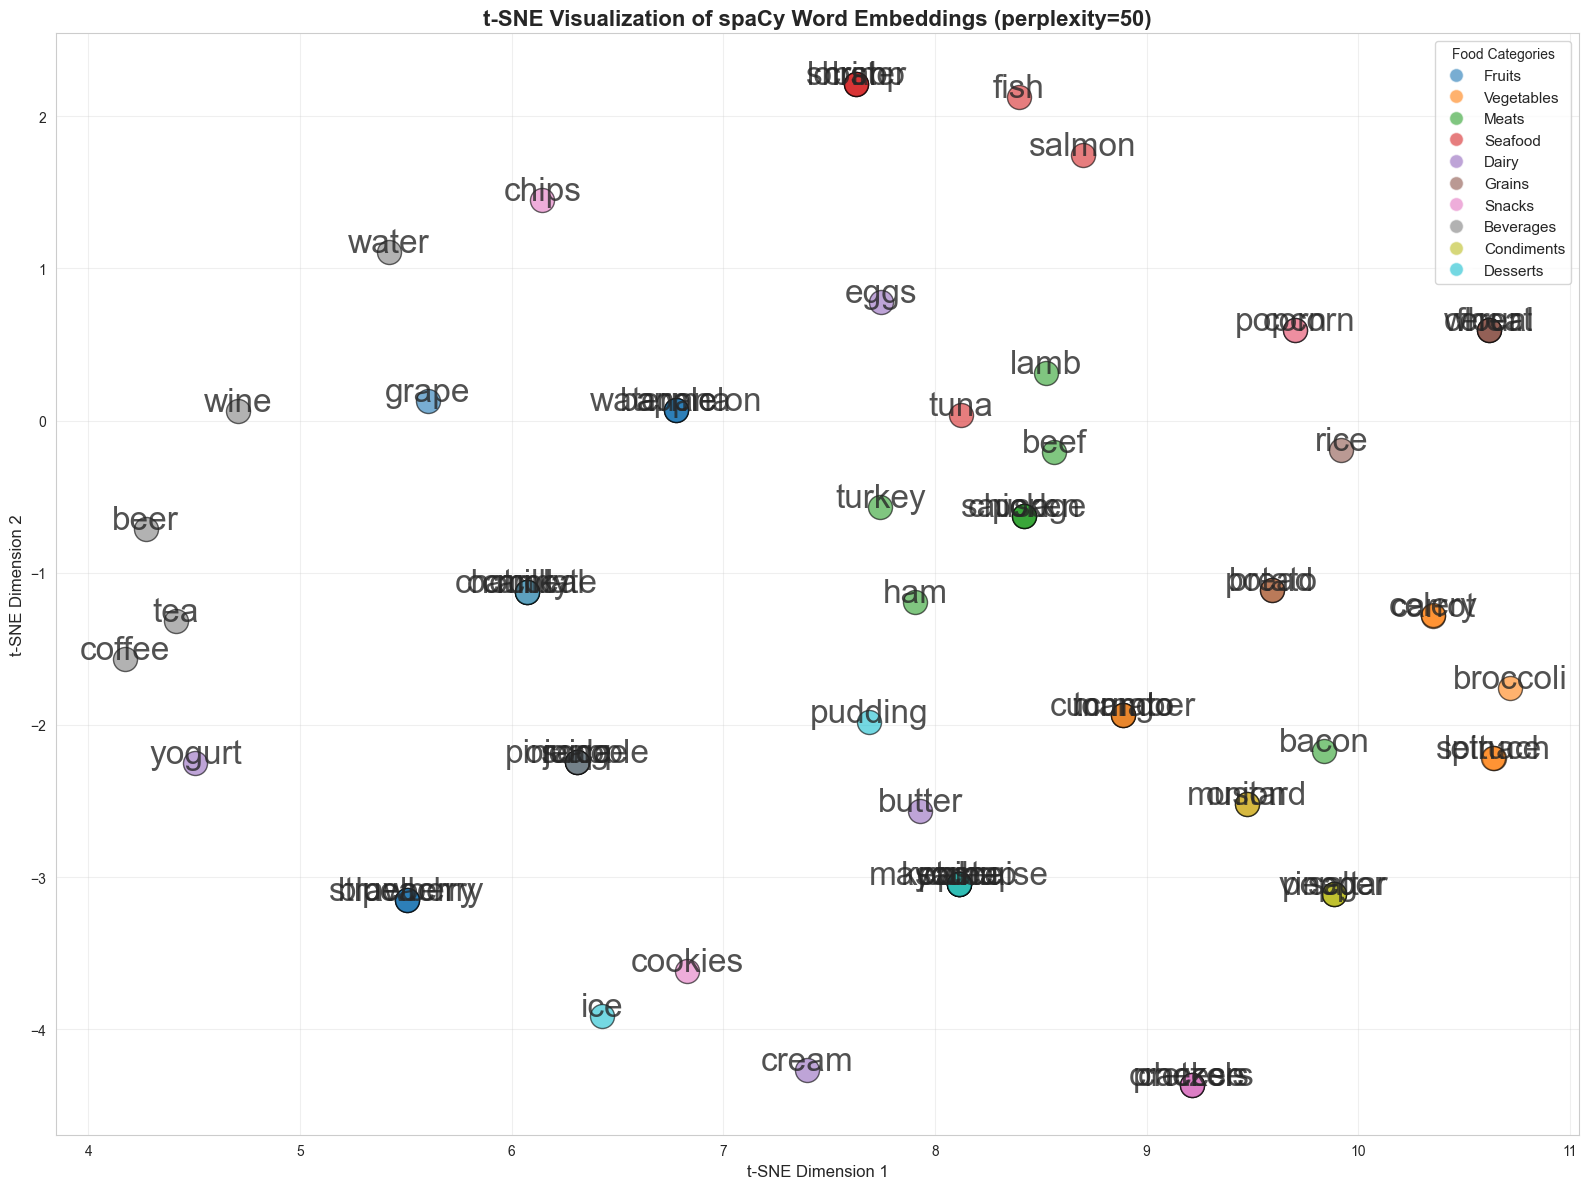

In [7]:
for perplexity in [2, 10, 50]:
    print(f"Applying t-SNE with perplexity={perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    word_vectors_2d = tsne.fit_transform(word_vectors)
    plot_embeddings(
        all_words, word_vectors_2d, word_categories,
        title=f't-SNE Visualization of spaCy Word Embeddings (perplexity={perplexity})'
    )

## **TASK 2: Analyze Clusters**

Let's examine which words cluster together and analyze the semantic relationships.

Create a DataFrame with the words, their categories, and their 2D coordinates to make analysis easier.

In [8]:
# Write your code here
results_df = pd.DataFrame({
    'word': all_words,
    'category': word_categories,
    'x': word_vectors_2d[:, 0],
    'y': word_vectors_2d[:, 1]
})

print("First 10 words and their 2D positions:")
print(results_df.head(10))

print("\nWords grouped by category:")
for category in categories:
    words_in_cat = results_df[results_df['category'] == category]['word'].tolist()
    print(f"\n{category} ({len(words_in_cat)} words):")
    print(f"  {', '.join(words_in_cat)}")

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.